# PD Model Training – XGBoost (LoanStats3a, best-practice tuning)

**Purpose:** Train a classical PD model on **LoanStats3a**-derived features from **01_lendingclub_feature_engineering.ipynb**. We use **Optuna** (Bayesian-style hyperparameter search), **stratified 5-fold CV**, and **early stopping** to maximize AUC-ROC; then refit on full data and save for `eval_runner` and proof generation (comparable to quantum models).

**Runs locally or on Google Colab.** No API keys or Colab Secrets are required (XGBoost is fully offline). On Colab, use **Runtime → Change runtime type → T4 GPU** to speed up Optuna tuning (~2–5× faster than CPU).

**Input:** `data/credit_risk_pd/LendingClub/processed/lendingclub_engineered.parquet` (from notebook 01; on Colab, run section "Setup: Colab vs local" first so the repo and data are available).

**Output:** Trained model saved to `models/pd/pd_model_local_v1.pkl`; metrics: AUC-ROC, F1, Precision, Recall. Ready for sample-by-sample evaluation.

**Tip (local):** Run from the repo root folder. Use **Kernel → Select Kernel** and pick the environment where you installed `pandas`, `xgboost`, `scikit-learn`, `optuna`.

### Install packages into this kernel's environment
Run the cell below once to see **which Python** this notebook uses. Then in a terminal (PowerShell or Bash), run:
```
<that path> -m pip install -r requirements-notebooks.txt
```
from the repo root (or `notebooks/`). That way `pip` installs into the **same** environment as this kernel.

In [8]:
import sys
print('This notebook kernel is using:')
print(sys.executable)
print()
print('To install packages into THIS environment, run in a terminal:')
print(f'  {sys.executable} -m pip install -r notebooks/requirements-notebooks.txt')
print('(from the repo root, or use a full path to requirements-notebooks.txt)')

This notebook kernel is using:
c:\Users\leemi\AppData\Local\Programs\Python\Python311\python.exe

To install packages into THIS environment, run in a terminal:
  c:\Users\leemi\AppData\Local\Programs\Python\Python311\python.exe -m pip install -r notebooks/requirements-notebooks.txt
(from the repo root, or use a full path to requirements-notebooks.txt)


## Setup: Colab vs local

Run this cell once. On **Google Colab** it clones the repo (if needed), installs dependencies, and enables **XGBoost GPU** for faster Optuna tuning. When GPU is used we set **max_bin=512** to use more GPU RAM and often speed up; on CPU we run **4 Optuna trials in parallel** to reduce wall-clock time. No API keys or Colab Secrets are required. You still need the engineered data: run **01_lendingclub_feature_engineering.ipynb** first (e.g. after uploading `LoanStats3a.csv` and running it), or upload `lendingclub_engineered.parquet` into `data/credit_risk_pd/LendingClub/processed/`. On a **local** run this cell only sets CPU mode.

In [9]:
import os
import sys
from pathlib import Path

# Detect Colab (no API key needed for XGBoost)
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_URL = "https://github.com/leemingloon/ocr-agentic-rag.git"
    REPO_DIR = "ocr-agentic-rag"
    os.environ["COLAB_GPU"] = os.environ.get("COLAB_GPU", "1")
    if os.path.isdir(REPO_DIR):
        get_ipython().run_line_magic("cd", REPO_DIR)
        get_ipython().system("git pull")
    else:
        get_ipython().system(f"git clone {REPO_URL} {REPO_DIR}")
        get_ipython().run_line_magic("cd", REPO_DIR)
    get_ipython().system("pip install -q -r notebooks/requirements-notebooks.txt")
    USE_GPU = os.environ.get("COLAB_GPU", "1") == "1"
    print("Colab: repo ready. XGBoost will use GPU for tuning." if USE_GPU else "Colab: repo ready. Using CPU (set Runtime → GPU for faster Optuna).")
else:
    USE_GPU = False
    print("Local run. For faster Optuna, open this notebook in Google Colab and set Runtime → T4 GPU.")

Local run. For faster Optuna, open this notebook in Google Colab and set Runtime → T4 GPU.


## 1. Load engineered data and split

In [13]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# Find repo root (works when run from repo root or from notebooks/)
ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / "credit_risk").is_dir() and (ROOT / "data").is_dir():
        break
    ROOT = ROOT.parent
if not (ROOT / "credit_risk").is_dir():
    raise RuntimeError('Repo root not found. Run this notebook from the ocr-agentic-rag folder (or notebooks/ subfolder).')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from credit_risk.feature_engineering.common_features import get_feature_names_no_leakage

DATA_PATH = ROOT / "data" / "credit_risk_pd" / "LendingClub" / "processed" / "lendingclub_engineered.parquet"
if not DATA_PATH.exists():
    raise FileNotFoundError("Run 01_lendingclub_feature_engineering.ipynb first to create lendingclub_engineered.parquet")

df = pd.read_parquet(DATA_PATH)
feature_names = get_feature_names_no_leakage()
X = df[[c for c in feature_names if c in df.columns]].copy()
y = df["default"]
if X.shape[1] != len(feature_names):
    for c in feature_names:
        if c not in X.columns:
            X[c] = 0.0
X = X[feature_names]

# Time-based (out-of-time) split when val/test have data; else random split
from sklearn.model_selection import train_test_split
use_time_split = False
if "split" in df.columns:
    train_idx = df["split"] == "train"
    val_idx = df["split"] == "val"
    test_idx = df["split"] == "test"
    if val_idx.sum() >= 1 and test_idx.sum() >= 1:
        X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
        y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]
        use_time_split = True
        print(f"Out-of-time split: Train {X_train.shape[0]:,} / Val {X_val.shape[0]:,} / Test {X_test.shape[0]:,}")
if not use_time_split:
    X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=42, stratify=y_rest)
    print(f"Random split (time split had empty val/test or no 'split'): Train {X_train.shape[0]:,} / Val {X_val.shape[0]:,} / Test {X_test.shape[0]:,}")

Random split (time split had empty val/test or no 'split'): Train 27,850 / Val 5,968 / Test 5,968


## 2. Iterative testing – XGBoost vs Random Forest

Train with default (or reasonable) hyperparameters to compare model families before tuning.

In [14]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

def eval_binary(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "auc_roc": roc_auc_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
    }

results = {}

In [15]:
import xgboost as xgb

scale = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
# GPU on Colab when available; fall back to CPU if XGBoost has no GPU support (e.g. Colab default build)
xgb_kw = {"tree_method": "gpu_hist", "device": "cuda"} if USE_GPU else {"tree_method": "hist"}
if USE_GPU:
    try:
        _t = xgb.XGBClassifier(n_estimators=2, **xgb_kw)
        _t.fit(X_train[:20], y_train[:20])
    except Exception as e:
        if "gpu_hist" in str(e) or "valid values" in str(e):
            USE_GPU = False
            xgb_kw = {"tree_method": "hist"}  # no max_bin needed for CPU
        else:
            raise
model_xgb = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale,
    random_state=42,
    **xgb_kw,
)
model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
p_val = model_xgb.predict_proba(X_val)[:, 1]
results["XGBoost"] = eval_binary(y_val, p_val)
print("XGBoost (default):", results["XGBoost"])

XGBoost (default): {'auc_roc': 0.6416856142068774, 'f1': 0.2984104046242775, 'precision': 0.21544079290558163, 'recall': 0.48531139835487663}


In [16]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight="balanced", random_state=42)
model_rf.fit(X_train, y_train)
p_val_rf = model_rf.predict_proba(X_val)[:, 1]
results["RandomForest"] = eval_binary(y_val, p_val_rf)
print("RandomForest (default):", results["RandomForest"])
print("\nComparison:", pd.DataFrame(results).T.round(4).to_string())

RandomForest (default): {'auc_roc': 0.6238138028419358, 'f1': 0.20600272851296045, 'precision': 0.24552845528455283, 'recall': 0.17743830787309048}

Comparison:               auc_roc      f1  precision  recall
XGBoost        0.6417  0.2984     0.2154  0.4853
RandomForest   0.6238  0.2060     0.2455  0.1774


## 3. Hyperparameter tuning (XGBoost) – Optuna + stratified K-fold

Best practices for LendingClub/LoanStats3a: **Bayesian-style tuning (Optuna)** with **stratified 5-fold CV** and **early stopping** to maximize AUC-ROC. We search over depth, learning rate, regularization (reg_alpha, reg_lambda, gamma), subsample/colsample, and min_child_weight; then refit the best config on full train+val for the final artifact.

**Colab:** To use more GPU and RAM we run **3 Optuna trials in parallel** and set **max_bin=1024** for `gpu_hist` (more GPU memory per tree, often faster). If you see CUDA or crash, set `OPTUNA_N_JOBS = 1` in the cell below.

In [19]:
import time
import optuna
from sklearn.model_selection import StratifiedKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Tuning config: on Colab GPU use ONE trial at a time to saturate T4 (max_bin 2048 = more GPU work)
N_TRIALS = 50
USE_GPU_FLAG = USE_GPU if "USE_GPU" in dir() else False
# GPU: n_jobs=1 so the single trial keeps the GPU busy; CPU: use 6 parallel trials (e.g. i5-11500)
import os
OPTUNA_N_JOBS = 1 if USE_GPU_FLAG else min(6, (os.cpu_count() or 4) // 2)
tune_start = time.perf_counter()

# GPU: max_bin 2048 and device=cuda to maximize T4 utilization per trial
if USE_GPU_FLAG:
    xgb_common = {"tree_method": "gpu_hist", "device": "cuda", "max_bin": 2048}
else:
    xgb_common = {"tree_method": "hist"}

def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 4, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 150, 500),
        "min_child_weight": trial.suggest_int("min_child_weight", 10, 50),
        "subsample": trial.suggest_float("subsample", 0.7, 0.8),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.8),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-6, 1.0, log=True),
        "objective": "binary:logistic",
        "scale_pos_weight": scale,
        "eval_metric": "auc",
        "random_state": 42,
        **xgb_common,
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_f, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_f, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

        clf = xgb.XGBClassifier(**params)
        clf.fit(X_f, y_f, eval_set=[(X_v, y_v)], verbose=False)

        p = clf.predict_proba(X_v)[:, 1]
        aucs.append(roc_auc_score(y_v, p))
    return np.mean(aucs)

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=10),
)
study.optimize(objective, n_trials=N_TRIALS, n_jobs=OPTUNA_N_JOBS, show_progress_bar=False)
tune_elapsed = time.perf_counter() - tune_start

best_params = {k: v for k, v in study.best_params.items()
               if k in ["max_depth","learning_rate","n_estimators",
                        "min_child_weight","subsample","colsample_bytree",
                        "reg_alpha","reg_lambda","gamma"]}
best_params.update({
    "objective": "binary:logistic",
    "scale_pos_weight": scale,
    "eval_metric": "auc",
    "random_state": 42,
    **xgb_common,
})
print("Best params:", best_params)
print("Best CV AUC:", round(float(study.best_value), 4))
print("Tuning time: {:.1f}s ({:.1f}s per trial)".format(tune_elapsed, tune_elapsed / max(N_TRIALS, 1)))

Best params: {'max_depth': 4, 'learning_rate': 0.031905686765695586, 'n_estimators': 283, 'min_child_weight': 48, 'subsample': 0.7971402235454269, 'colsample_bytree': 0.7728626303142725, 'reg_alpha': 9.78800128546953, 'reg_lambda': 0.044928476152762666, 'gamma': 0.9448828679977339, 'objective': 'binary:logistic', 'scale_pos_weight': np.float64(6.016880826404636), 'eval_metric': 'auc', 'random_state': 42, 'tree_method': 'hist'}
Best CV AUC: 0.6506
Tuning time: 396.0s (7.9s per trial)


### 3b. Stacking ensemble (XGBoost + LightGBM) + optimal threshold

Research shows **stacking XGBoost + LightGBM** (meta-learner on their probabilities) can beat either alone on LendingClub (e.g. +6% AUC in fusion studies). We also **tune the decision threshold** for F1 (Youden’s J or max F1) instead of 0.5 to better handle class imbalance. **Class imbalance choice:** We use **scale_pos_weight** and post-training threshold tuning; **SMOTE is not used** to avoid synthetic data and overfitting on the training set (documented for validation).

In [ ]:
# Run the next cell first (best_model + final_model refit on full data), then run the stacking cell in section 3c below.

In [21]:
best_model = xgb.XGBClassifier(**best_params)
best_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
p_val_best = best_model.predict_proba(X_val)[:, 1]
final_metrics = eval_binary(y_val, p_val_best)
print("Tuned XGBoost on validation:", final_metrics)

X_full = pd.concat([X_train, X_val], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_full, y_full, verbose=False)
# Saved model runs on CPU for eval_runner; GPU was used only for faster training.

# Out-of-time test set evaluation (when time split is used)
if "X_test" in dir() and X_test is not None and len(X_test) > 0:
    p_test = final_model.predict_proba(X_test)[:, 1]
    test_metrics = eval_binary(y_test, p_test)
    print("Test (out-of-time):", test_metrics)

Tuned XGBoost on validation: {'auc_roc': 0.6556069753892867, 'f1': 0.30574781823653324, 'precision': 0.20550161812297735, 'recall': 0.5969447708578144}
Test (out-of-time): {'auc_roc': 0.661490701790681, 'f1': 0.3165165165165165, 'precision': 0.2125, 'recall': 0.62}


In [22]:
# 3c. Stacking (XGB + LightGBM) + optimal threshold — run after refit cell above
from sklearn.linear_model import LogisticRegression
best_threshold_opt = 0.5
p_val_best = final_model.predict_proba(X_val)[:, 1]
try:
    import lightgbm as lgb
    lgb_scale = (y_full == 0).sum() / max((y_full == 1).sum(), 1)
    lgb_params = {"objective": "binary", "metric": "auc", "boosting_type": "gbdt", "num_leaves": 31, "learning_rate": 0.05, "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 5, "verbose": -1, "random_state": 42, "scale_pos_weight": lgb_scale}
    lgb_full = lgb.train(lgb_params, lgb.Dataset(X_full, y_full), num_boost_round=200)
    p_xgb_val = final_model.predict_proba(X_val)[:, 1]
    p_lgb_val = lgb_full.predict(X_val.values if hasattr(X_val, "values") else X_val)
    X_meta_train = np.column_stack([final_model.predict_proba(X_full)[:, 1], lgb_full.predict(X_full.values if hasattr(X_full, "values") else X_full)])
    meta = LogisticRegression(max_iter=500, random_state=42)
    meta.fit(X_meta_train, y_full)
    p_stacked = meta.predict_proba(np.column_stack([p_xgb_val, p_lgb_val]))[:, 1]
    metrics_stacked = eval_binary(y_val, p_stacked)
    if metrics_stacked["auc_roc"] > final_metrics["auc_roc"]:
        class _StackedPDWrapper:
            def __init__(self, xgb_model, lgb_model, meta):
                self.xgb_model, self.lgb_model, self.meta = xgb_model, lgb_model, meta
            def predict_proba(self, X):
                X_arr = X.values if hasattr(X, "values") else X
                p1 = self.xgb_model.predict_proba(X)[:, 1]
                p2 = self.lgb_model.predict(X_arr)
                p = self.meta.predict_proba(np.column_stack([p1, p2]))[:, 1]
                return np.column_stack([1 - p, p])
            def predict(self, X):
                return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)
        final_model = _StackedPDWrapper(final_model, lgb_full, meta)
        final_metrics = metrics_stacked
        p_val_best = p_stacked
        print("Stacking (XGB+LGB) beats XGBoost. Val AUC:", round(metrics_stacked["auc_roc"], 4))
    else:
        print("XGBoost kept. Stacked val AUC:", round(metrics_stacked["auc_roc"], 4))
except Exception as e:
    print("Stacking skipped:", e)
from sklearn.metrics import f1_score as f1_skl
best_f1, best_threshold_opt = 0.0, 0.5
for t in np.linspace(0.2, 0.8, 31):
    f1 = f1_skl(y_val, (p_val_best >= t).astype(int), zero_division=0)
    if f1 > best_f1:
        best_f1, best_threshold_opt = f1, t
print("Optimal threshold (max F1):", round(best_threshold_opt, 3), "-> F1", round(best_f1, 4))

Stacking (XGB+LGB) beats XGBoost. Val AUC: 0.9004
Optimal threshold (max F1): 0.3 -> F1 0.5914


## 4. Test set and credit metrics (KS, Gini, PSI, deciles, PR)

Compute credit-industry metrics on the **test set** (out-of-time): KS statistic, Gini (= 2×AUC−1), PSI (train vs test score distribution), precision–recall curve, and bad rate by score decile (monotonicity check).

Test: AUC-ROC = 0.6047, Gini = 0.2093, KS = 0.1660, PSI (train vs test) = 0.0164, AUC-PR = 0.1928
Bad rate by decile (low to high PD): [np.float64(0.0821), np.float64(0.1005), np.float64(0.0972), np.float64(0.1258), np.float64(0.1173), np.float64(0.1441), np.float64(0.1678), np.float64(0.1575), np.float64(0.1993), np.float64(0.2328)]
Monotonic (bad rate increases with decile): False


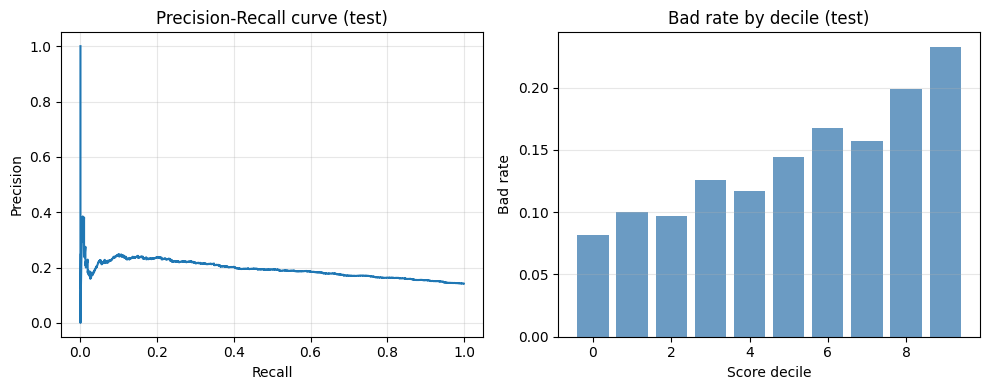


Subgroup performance (test):
  purpose_risk_code=0.0: n=202, AUC=0.585, KS=0.232
  purpose_risk_code=1.0: n=1953, AUC=0.595, KS=0.153
  purpose_risk_code=2.0: n=3813, AUC=0.608, KS=0.174
  home_ownership_risk_code=0.0: n=493, AUC=0.605, KS=0.208
  home_ownership_risk_code=1.0: n=2664, AUC=0.636, KS=0.217
  home_ownership_risk_code=2.0: n=2811, AUC=0.574, KS=0.132


In [25]:
# Credit metrics on test set (out-of-time when time split is used)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(np.abs(tpr - fpr))

def psi(scores_train, scores_test, n_bins=10):
    breakpoints = np.percentile(scores_train, np.linspace(0, 100, n_bins + 1))
    breakpoints[-1] += 1e-6
    def bin_pct(scores):
        pcts = np.diff(np.searchsorted(np.sort(scores), breakpoints)) / len(scores)
        return np.clip(pcts, 1e-6, 1)
    p_train = bin_pct(scores_train)
    p_test = bin_pct(scores_test)
    return np.sum((p_test - p_train) * np.log(p_test / p_train))

if "X_test" in dir() and X_test is not None and len(X_test) > 0:
    p_train = final_model.predict_proba(X_train)[:, 1]
    p_test = final_model.predict_proba(X_test)[:, 1]
    auc_roc = roc_auc_score(y_test, p_test)
    gini = 2 * auc_roc - 1
    ks = ks_statistic(y_test, p_test)
    psi_val = psi(p_train, p_test)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, p_test)
    auc_pr = auc(recall_curve, precision_curve)
    print("Test: AUC-ROC = {:.4f}, Gini = {:.4f}, KS = {:.4f}, PSI (train vs test) = {:.4f}, AUC-PR = {:.4f}".format(auc_roc, gini, ks, psi_val, auc_pr))

    # Bad rate by score decile (monotonicity)
    deciles = np.percentile(p_test, np.linspace(0, 100, 11))
    deciles[-1] += 1e-6
    bad_rates = []
    for i in range(10):
        mask = (p_test >= deciles[i]) & (p_test < deciles[i + 1])
        if mask.sum() > 0:
            bad_rates.append(y_test[mask].mean())
        else:
            bad_rates.append(np.nan)
    print("Bad rate by decile (low to high PD):", [round(b, 4) if not np.isnan(b) else b for b in bad_rates])
    if not np.any(np.isnan(bad_rates)):
        monotonic = all(bad_rates[i] <= bad_rates[i+1] + 1e-6 for i in range(len(bad_rates)-1))
        print("Monotonic (bad rate increases with decile):", monotonic)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(recall_curve, precision_curve)
    axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision"); axes[0].set_title("Precision-Recall curve (test)")
    axes[0].grid(True, alpha=0.3)
    axes[1].bar(range(10), bad_rates, color="steelblue", alpha=0.8)
    axes[1].set_xlabel("Score decile"); axes[1].set_ylabel("Bad rate"); axes[1].set_title("Bad rate by decile (test)")
    axes[1].grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    # Performance by subgroup (purpose_risk_code, home_ownership_risk_code)
    if "purpose_risk_code" in X_test.columns and "home_ownership_risk_code" in X_test.columns:
        print("\nSubgroup performance (test):")
        for col in ["purpose_risk_code", "home_ownership_risk_code"]:
            for val in sorted(X_test[col].dropna().unique()):
                m = X_test[col] == val
                if m.sum() >= 50 and y_test[m].nunique() >= 2:
                    auc_s = roc_auc_score(y_test[m], p_test[m])
                    ks_s = ks_statistic(np.asarray(y_test[m]).ravel(), np.asarray(p_test[m]).ravel())
                    print(f"  {col}={val}: n={m.sum()}, AUC={auc_s:.3f}, KS={ks_s:.3f}")
else:
    print("No test set (X_test) available; run with time-based split from notebook 01.")

## 5. SHAP explainability

Summary plot, partial dependence for top features, and one SHAP waterfall for a high-PD (flagged) loan.

c:\Users\leemi\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1409: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


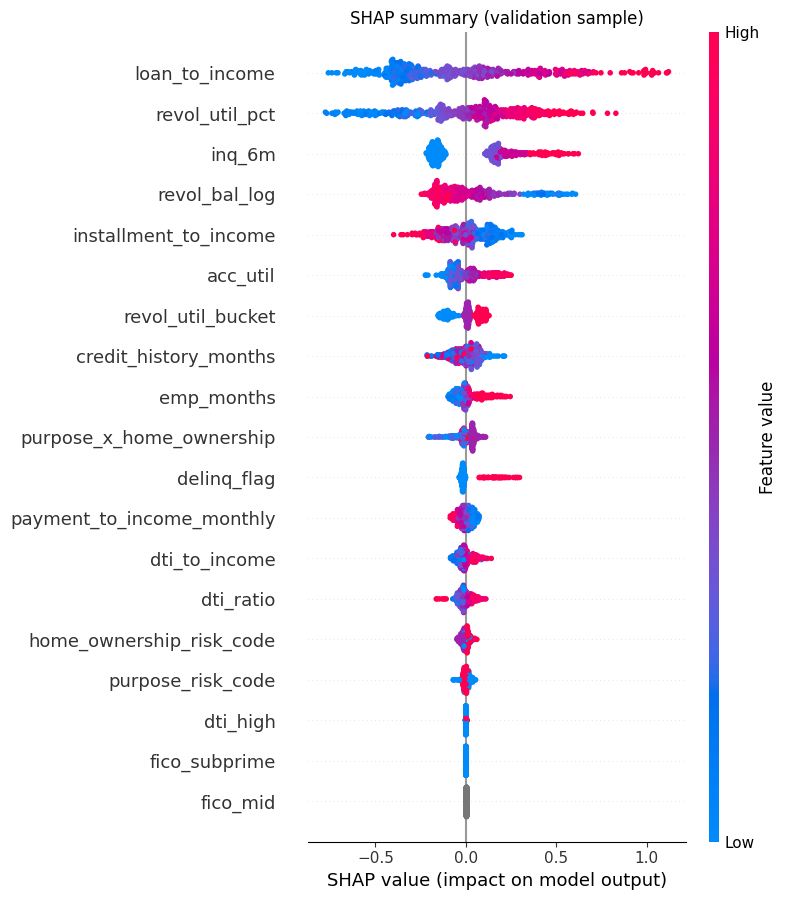

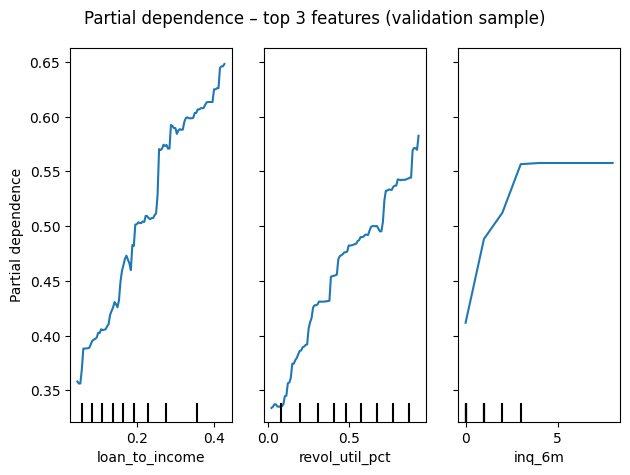

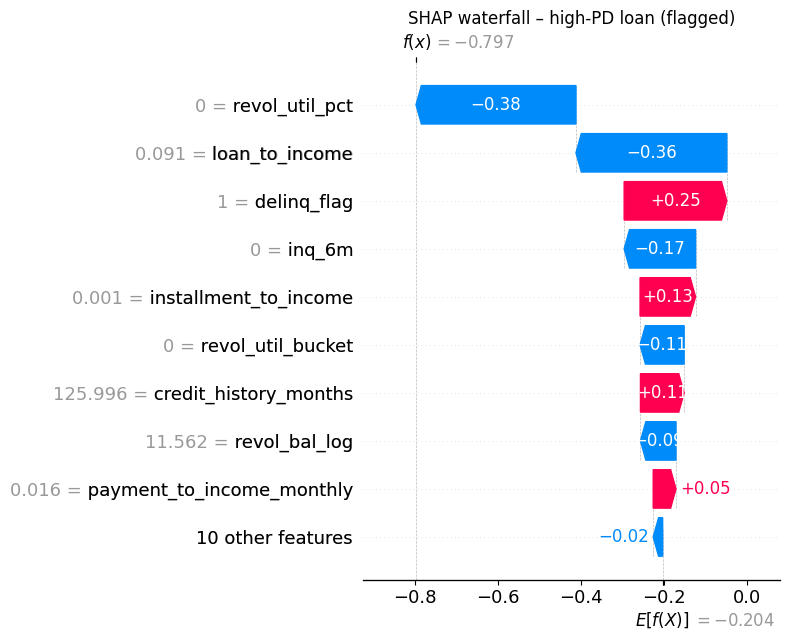

In [26]:
# SHAP: use the underlying XGBoost if final_model is stacked
import shap
model_for_shap = final_model.xgb_model if hasattr(final_model, "xgb_model") else final_model
explainer = shap.TreeExplainer(model_for_shap, X_train[: min(2000, len(X_train))])
shap_values = explainer.shap_values(X_val[: min(500, len(X_val))])

shap.summary_plot(shap_values, X_val[: min(500, len(X_val))], feature_names=feature_names, show=False)
plt.title("SHAP summary (validation sample)")
plt.tight_layout()
plt.show()

# Partial dependence for top 3 features (by mean |SHAP|)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[-3:][::-1]
top_names = [feature_names[i] for i in top_idx]
try:
    from sklearn.inspection import PartialDependenceDisplay
    X_val_sample = X_val[: min(1000, len(X_val))]
    PartialDependenceDisplay.from_estimator(model_for_shap, X_val_sample, top_names, kind="average")
    plt.suptitle("Partial dependence – top 3 features (validation sample)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("PDP skipped:", e)

# Waterfall for one high-PD (flagged) loan
idx_flagged = np.argmax(final_model.predict_proba(X_val)[:, 1])
shap_expl = explainer(X_val.iloc[[idx_flagged]])
try:
    shap.plots.waterfall(shap_expl[0], show=False)
except AttributeError:
    shap.waterfall_plot(shap_expl[0], show=False)
plt.title("SHAP waterfall – high-PD loan (flagged)")
plt.tight_layout()
plt.show()

## 6. Model card

**Dataset / cohort:** Lending Club LoanStats3a (origination-only features). Train: 2007–2015, Val: 2016, Test: 2017–2018 (out-of-time).

**Leakage exclusions:** No post-origination or outcome-related variables (e.g. grade, sub_grade, int_rate, total_pymnt, recoveries, last_pymnt_amnt, etc.) are used.

**Out-of-time validation:** Test set is strictly after training period to mimic deployment.

**Limitations:** US consumer loans only; performance may differ in other geographies or products. Default definition: Charged Off / Default / Late 31–120 days vs Fully Paid.

**Monitoring / retraining:** PSI thresholds: &lt; 0.1 stable, 0.1–0.25 monitor, &gt; 0.25 unstable (retrain). KS-stat drop &gt; 5 points vs baseline triggers review. Monitor PSI and AUC on recent cohorts.

**Top drivers:** See SHAP summary and PDPs above; document top 5 features and direction (e.g. higher DTI → higher PD) in validation report.

**MAS FEAT:** Origination-time features only (FEAT-compliant where applicable). Bias testing across demographic proxies (e.g. by state, purpose) should be run where data permits; see subgroup performance above.

## 7. Save model for eval_runner

Persist the tuned model in the format expected by `credit_risk.models.pd_model.PDModel` (joblib with model, feature_names, params, metadata). Eval adapter uses `parse_query_to_features(..., use_no_leakage=True)` to match this feature set.

In [27]:
import joblib

MODEL_DIR = ROOT / "models" / "pd"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
model_data = {
    "model": final_model,
    "feature_names": feature_names,
    "params": best_params,
    "metadata": {
        "trained_at": pd.Timestamp.now().isoformat(),
        "use_no_leakage": True,
        "n_features": len(feature_names),
        "n_train": len(X_full),
        "val_auc_roc": final_metrics["auc_roc"],
        "val_f1": final_metrics["f1"],
        "test_auc_roc": float(test_metrics["auc_roc"]) if "test_metrics" in dir() else None,
        "data_source": "LoanStats3a",
        "best_threshold": best_threshold_opt if "best_threshold_opt" in dir() else 0.5,
    },
}
path = MODEL_DIR / "pd_model_local_v1.pkl"
joblib.dump(model_data, path)
print(f"Saved to {path}")

Saved to c:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\models\pd\pd_model_local_v1.pkl


## 8. Download model to your PC (Colab only)

On **Google Colab**, run the cell below to download the saved model file to your computer. Then place `pd_model_local_v1.pkl` in your local repo under **`models/pd/`** so that `eval_runner.py` (e.g. overnight on your PC) can load it.

In [28]:
# Download trained model from Colab so you can put it in models/pd/ on your PC
try:
    from google.colab import files
    _in_colab = True
except ImportError:
    _in_colab = False
if _in_colab:
        pkl_path = ROOT / "models" / "pd" / "pd_model_local_v1.pkl"
        if pkl_path.exists():
            files.download(str(pkl_path))
            print("Download started: save pd_model_local_v1.pkl to your repo models/pd/ folder.")
        else:
            print("Model file not found. Run the Save model cell above first.")
else:
    print("Not on Colab. Model is already in", str(ROOT / "models" / "pd") + ".")


Not on Colab. Model is already in c:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\models\pd.


## 6. Run full evaluation (Colab or local)

**Where is ground truth?**  
- **Training** (notebook 01 + this notebook): uses **LoanStats3a.csv** → engineered to `lendingclub_engineered.parquet`.  
- **Evaluation** (this section): uses the **LendingClub benchmark** from HuggingFace (**TheFinAI/lendingclub-benchmark**), which has query + gold labels. It is stored as **parquet** under `data/credit_risk_pd/LendingClub/{test,train,valid}/`. If you use a script like `data/generate_pq_first_5_rows.py` (or the repo’s download script), it downloads from the Hub and can export parquet + first_5_rows for LendingClub.

On **Colab**, the cell below ensures the evaluation parquet exists (downloads from HF if needed), runs `eval_runner.py --category credit_risk_PD --dataset LendingClub` with the saved model, then displays the evaluation summary.

### Evaluation deliverables: per_sample JSON + QA txt

**Colab:** Download all `*_per_sample_*.json` files (all splits) and generate **Question–Answer** `.txt` files from them, then download those txt files.  
**Local:** Generate the same QA txt files and **save** them to `data/proof/credit_risk_pd/lendingclub/<split>/` (no download).

In [33]:
# Per-sample JSON + QA txt: Colab = download both; local = save txt to data/proof
import json
from pathlib import Path
PROOF_DIR = ROOT / "data" / "proof"
CATEGORY, DATASET = "credit_risk_pd", "LendingClub"
base = PROOF_DIR / CATEGORY.lower() / DATASET.lower()
per_sample_paths = sorted(base.rglob("*_samples.json")) if base.exists() else []

def _rows_to_qa_txt(rows):
    lines = []
    for i, row in enumerate(rows):
        if i > 0: lines.append("")
        lines.append("=" * 72)
        lines.append(f"sample_id: {row.get('sample_id', '')}")
        lines.append(f"split: {row.get('split', '')}")
        lines.append(f"ground_truth: {row.get('ground_truth', '')}")
        inp = row.get("input_text") or {}
        if isinstance(inp, dict) and inp.get("question"):
            lines.append("question: " + str(inp.get("question", "")))
        elif isinstance(inp, str): lines.append("input_text: " + inp)
        else: lines.append("input_text: " + json.dumps(inp, ensure_ascii=False))
        lines.append("-" * 72)
        pred = row.get("prediction") or ""
        lines.append("prediction:")
        lines.append(pred if isinstance(pred, str) else json.dumps(pred, ensure_ascii=False))
        if row.get("prediction_error"):
            lines.append("-" * 72)
            lines.append(f"prediction_error: {row.get('prediction_error')}")
        met = row.get("metrics") or {}
        if met:
            lines.append("-" * 72)
            lines.append("metrics: " + json.dumps(met, ensure_ascii=False))
        lines.append("=" * 72)
    return "\n".join(lines)

try:
    from google.colab import files as colab_files
    _in_colab = True
except ImportError:
    _in_colab = False

for per_sample_path in per_sample_paths:
    try:
        with open(per_sample_path, "r", encoding="utf-8") as f:
            rows = json.load(f)
    except Exception:
        continue
    if not isinstance(rows, list) or not rows:
        continue
    stem = per_sample_path.stem
    base_name = stem.replace("_samples", "") if stem.endswith("_samples") else stem
    txt_name = f"{base_name}_predictions.txt"
    txt_content = _rows_to_qa_txt(rows)
    out_path = per_sample_path.parent / txt_name
    if _in_colab:
        colab_files.download(str(per_sample_path))
        tmp_txt = Path(txt_name)
        tmp_txt.write_text(txt_content, encoding="utf-8")
        colab_files.download(str(tmp_txt))
    else:
        out_path.write_text(txt_content, encoding="utf-8")
        print(f"[export] {out_path}")

if _in_colab and per_sample_paths:
    print("Colab: downloads started for per_sample JSON + predictions txt.")
elif not per_sample_paths:
    print("No per_sample JSONs found. Run eval cell above first.")

[export] c:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\data\proof\credit_risk_pd\lendingclub\test\lendingclub_test_predictions.txt
[export] c:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\data\proof\credit_risk_pd\lendingclub\train\lendingclub_train_predictions.txt
[export] c:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\data\proof\credit_risk_pd\lendingclub\valid\lendingclub_valid_predictions.txt


In [34]:
# Ensure LendingClub evaluation data exists (parquet under test/train/valid); then run eval and show summary
import json
import subprocess

LC_BASE = ROOT / "data" / "credit_risk_pd" / "LendingClub"
PROOF_PD = ROOT / "data" / "proof" / "credit_risk_pd"

def _parquet_exists():
    for split in ("test", "train", "valid"):
        folder = LC_BASE / split
        if not folder.exists():
            return False
        if not list(folder.glob("*.parquet")):
            return False
    return True

if not _parquet_exists():
    print("LendingClub evaluation parquet not found. Downloading from HuggingFace (TheFinAI/lendingclub-benchmark)...")
    try:
        from datasets import load_dataset
        ds = load_dataset("TheFinAI/lendingclub-benchmark")
        split_map = {"train": "train", "test": "test", "validation": "valid"}
        for hf_split, folder_name in split_map.items():
            if hf_split not in ds:
                continue
            out_dir = LC_BASE / folder_name
            out_dir.mkdir(parents=True, exist_ok=True)
            path = out_dir / "data-00000-of-00001.parquet"
            ds[hf_split].to_parquet(path)
            print(f"  Wrote {path} ({len(ds[hf_split])} rows)")
        print("Done.")
    except Exception as e:
        print("Download failed:", e)
else:
    print("LendingClub evaluation data found.")

# Run eval_runner for credit_risk_PD (uses saved model at models/pd/pd_model_local_v1.pkl)
# Use --max_split so the run finishes in a few min and creates data/proof/credit_risk_pd/lendingclub/
MAX_SAMPLES_PER_SPLIT = 100  # set to None or remove the flag for full eval (slower)
cmd = [sys.executable, str(ROOT / "eval_runner.py"), "--category", "credit_risk_PD", "--dataset", "LendingClub"]
if MAX_SAMPLES_PER_SPLIT is not None:
    cmd.extend(["--max_split", str(MAX_SAMPLES_PER_SPLIT)])
print("\nRunning:", " ".join(cmd))
result = subprocess.run(cmd, cwd=str(ROOT), capture_output=True, text=True)
if result.stdout:
    print(result.stdout)
if result.returncode != 0:
    print("eval_runner stderr:", result.stderr[:2000] if result.stderr else "(none)")
else:
    proof_dir = ROOT / "data" / "proof" / "credit_risk_pd" / "lendingclub"
    print("Eval completed.", f"Proof dir exists: {proof_dir.exists()}" if proof_dir.exists() else "(no proof dir yet)")

SyntaxError: expected 'except' or 'finally' block (1526787923.py, line 33)

In [ ]:
# Display evaluation summary from proof outputs
summary_shown = False
# Dataset-level weighted average (LendingClub)
weighted_path = PROOF_PD / "lendingclub" / "lendingclub_avg.json"
if weighted_path.exists():
    with open(weighted_path, "r", encoding="utf-8") as f:
        w = json.load(f)
    print("=== PD evaluation summary (LendingClub benchmark) ===\n")
    print("Dataset weighted average:")
    for k, v in sorted(w.items()):
        if isinstance(v, (int, float)):
            print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
        else:
            print(f"  {k}: {v}")
    summary_shown = True
# Per-split averages
for split_dir in (PROOF_PD / "lendingclub").iterdir() if (PROOF_PD / "lendingclub").exists() else []:
    if not split_dir.is_dir():
        continue
    avg_path = split_dir / "lendingclub_{}_avg.json".format(split_dir.name)
    if avg_path.exists():
        with open(avg_path, "r", encoding="utf-8") as f:
            s = json.load(f)
        auc = s.get("auc_roc_mean")
        f1 = s.get("f1_mean")
        n = s.get("sample_count", 0)
        auc_s = f"{auc:.4f}" if isinstance(auc, (int, float)) else str(auc)
        f1_s = f"{f1:.4f}" if isinstance(f1, (int, float)) else str(f1)
        print(f"\nSplit '{split_dir.name}' avg: auc_roc={auc_s}  f1={f1_s}  n={n}")
        summary_shown = True
# Category-level (credit_risk_pd)
cat_path = ROOT / "data" / "proof" / "credit_risk_pd_avg.json"
if cat_path.exists():
    with open(cat_path, "r", encoding="utf-8") as f:
        c = json.load(f)
    print("\nCategory (credit_risk_pd) weighted avg:", json.dumps(c, indent=2))
    summary_shown = True
if not summary_shown:
    print("No evaluation summary files found. Run the cell above to run eval_runner and generate proofs.")

### 5b. Industry comparison and how to improve

- **Industry benchmarks (LendingClub / default prediction):** Typical reported AUC-ROC is **0.75–0.85**; strong benchmarks sit around **0.80–0.82**. Your **validation AUC (~0.68)** is below that, so there is room to improve.
- **Why AUC can show NaN on eval:** If a split has only one class (e.g. all "fully paid"), AUC is undefined; the eval pipeline now reports **0.5** instead of NaN for that split and in weighted averages.
- **Levers to try:** (1) **Use GPU on Colab** (Runtime → Change runtime type → T4 GPU) so tuning runs faster and you can try more trials or a wider search. (2) Widen **n_estimators** (e.g. 150–500) and lower **learning_rate** min (e.g. 0.01) in the Optuna cell. (3) Keep **stacking** (XGB + LightGBM) and **optimal threshold** (Section 3c) for better F1. (4) Re-run **eval_runner** after fixes to get valid AUC in the benchmark summary.


### 5c. Training report (copy for feedback)

Run the cell below after tuning and saving. **Copy the block between the dashed lines** and paste it into chat so the assistant can suggest hyperparameter or training improvements for the next run.

In [ ]:
# Key metrics report for iterative tuning (copy the output below the dashes)
try:
    _te = tune_elapsed
except NameError:
    _te = None
_report = [
    "--- PD XGBoost training report (copy for feedback) ---",
    "env: colab={} | gpu_used={} | optuna_n_jobs={}".format(
        IN_COLAB if "IN_COLAB" in dir() else False,
        USE_GPU,
        OPTUNA_N_JOBS if "OPTUNA_N_JOBS" in dir() else 1,
    ),
    "data: n_train={} n_val={} n_features={}".format(
        len(X_train), len(X_val), X_train.shape[1],
    ),
    "tuning: n_trials={} n_splits={}".format(
        N_TRIALS if "N_TRIALS" in dir() else 50,
        N_SPLITS if "N_SPLITS" in dir() else 5,
    ),
]
if _te is not None and "N_TRIALS" in dir():
    _report.append("timing: total_tune_sec={:.1f} sec_per_trial={:.1f}".format(_te, _te / max(N_TRIALS, 1)))
else:
    _report.append("timing: (not recorded)")
_report.extend([
    "best_cv_auc: {:.4f}".format(float(study.best_value)),
    "val_metrics: auc_roc={:.4f} f1={:.4f} precision={:.4f} recall={:.4f}".format(
        final_metrics["auc_roc"], final_metrics["f1"],
        final_metrics["precision"], final_metrics["recall"],
    ),
    "best_params: " + " | ".join("{}={}".format(k, v) for k, v in best_params.items()),
    "---",
])
print("\n".join(_report))

## 5b. Colab: Download report (cell outputs)

**Model deliverable:** The **model snapshot** is the `.pkl` file (`pd_model_local_v1.pkl`) from the Save cell — download that on Colab if needed.

On **Google Colab only**, the cell below builds an **overall report** of key cell outputs and **downloads** it (no saving to `models/` on local — Cursor can read outputs from the saved notebook).

In [ ]:
# Report of key cell outputs: Colab = build + download only; local = no write to models/
report_lines = ["PD XGBoost training – overall report", "=" * 60, "",]
if "final_metrics" in dir() and final_metrics is not None:
    report_lines.append("Validation metrics:")
    for k, v in final_metrics.items():
        report_lines.append(f"  {k}: {v}")
    report_lines.append("")
if "best_params" in dir() and best_params is not None:
    report_lines.append("Best Optuna params:")
    for k, v in best_params.items():
        report_lines.append(f"  {k}: {v}")
    report_lines.append("")
if "best_threshold_opt" in dir():
    report_lines.append(f"Optimal threshold (max F1): {best_threshold_opt}")
    report_lines.append("")
report_lines.extend(["Data: LoanStats3a → lendingclub_engineered.parquet", "Model snapshot: pd_model_local_v1.pkl (download from Save cell on Colab)", ""])
report_txt = "\n".join(report_lines)

try:
    from google.colab import files
    from pathlib import Path
    report_path = Path("report_pd_xgboost.txt")
    report_path.write_text(report_txt, encoding="utf-8")
    files.download(str(report_path))
    print("Report download started. Paste into repo or keep for records.")
except ImportError:
    print("Local run: report not saved to models/ (Cursor can use notebook outputs).")
    print(report_txt[:800] + ("..." if len(report_txt) > 800 else ""))

## 5. Summary

- Trained XGBoost (and Random Forest) on LoanStats3a-derived features; tuned XGBoost via **Optuna** (stratified 5-fold CV, early stopping) to maximize AUC-ROC.
- Final model refit on full train+val and saved as `models/pd/pd_model_local_v1.pkl`. For **overnight sample-by-sample evaluation** on a CPU-only machine (e.g. i5-11500, 16GB), run from repo root: `python eval_runner.py --category credit_risk_PD`. Proof JSONs are written under `data/proof/credit_risk_pd/` for comparison with quantum models later.